In [77]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

In [78]:
df = pd.read_csv("/content/hmeq.csv")

print(df.head())

   BAD  LOAN  MORTDUE     VALUE   REASON     JOB   YOJ  DEROG  DELINQ  \
0    1  1100  25860.0   39025.0  HomeImp   Other  10.5    0.0     0.0   
1    1  1300  70053.0   68400.0  HomeImp   Other   7.0    0.0     2.0   
2    1  1500  13500.0   16700.0  HomeImp   Other   4.0    0.0     0.0   
3    1  1500      NaN       NaN      NaN     NaN   NaN    NaN     NaN   
4    0  1700  97800.0  112000.0  HomeImp  Office   3.0    0.0     0.0   

        CLAGE  NINQ  CLNO  DEBTINC  
0   94.366667   1.0   9.0      NaN  
1  121.833333   0.0  14.0      NaN  
2  149.466667   1.0  10.0      NaN  
3         NaN   NaN   NaN      NaN  
4   93.333333   0.0  14.0      NaN  


In [79]:
y = df["BAD"]
X = df.drop("BAD", axis=1)

X = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

mlp = MLPClassifier(max_iter=300)
mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=300)

In [82]:
models = ["LogReg", "kNN", "DT", "RF", "NN"]
accuracies = [
    accuracy_score(y_test, lr.predict(X_test)),
    accuracy_score(y_test, knn.predict(X_test)),
    accuracy_score(y_test, dt.predict(X_test)),
    accuracy_score(y_test, rf.predict(X_test)),
    accuracy_score(y_test, mlp.predict(X_test)),
]

for m, a in zip(models, accuracies):
    print(f"{m}: {a:.3f}")

LogReg: 0.815
kNN: 0.864
DT: 0.868
RF: 0.914
NN: 0.893


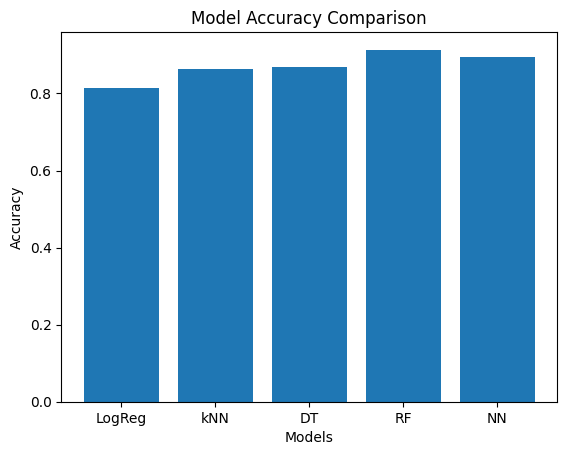

In [83]:
plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

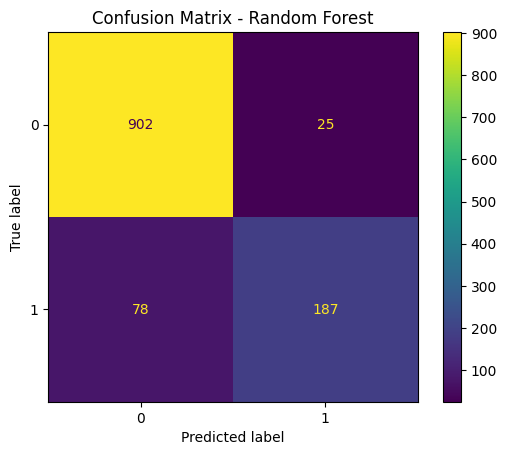

In [84]:
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [85]:
print("Classification Report (Random Forest):\n")
print(classification_report(y_test, rf.predict(X_test)))

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       927
           1       0.88      0.71      0.78       265

    accuracy                           0.91      1192
   macro avg       0.90      0.84      0.87      1192
weighted avg       0.91      0.91      0.91      1192



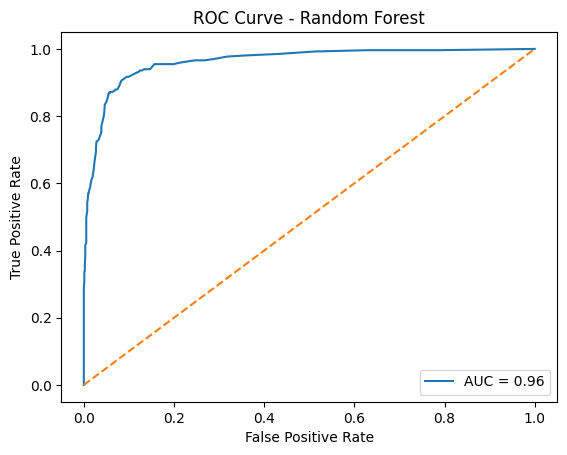

In [86]:
y_proba = rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

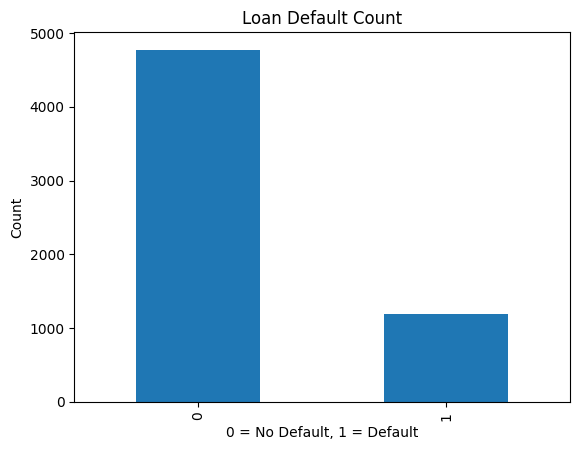

In [87]:
df["BAD"].value_counts().plot(kind="bar")
plt.title("Loan Default Count")
plt.xlabel("0 = No Default, 1 = Default")
plt.ylabel("Count")
plt.show()

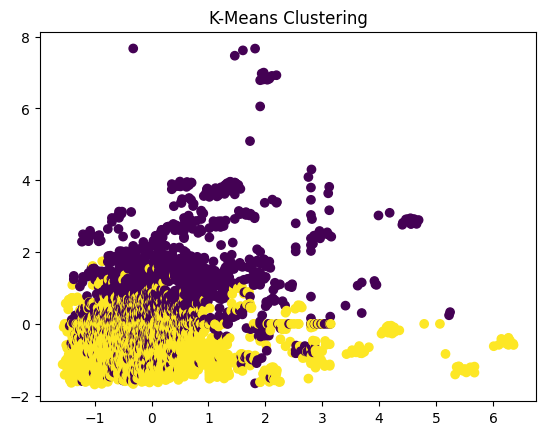

In [88]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.title("K-Means Clustering")
plt.show()

In [90]:
sample = pd.DataFrame([{
    "LOAN": 10000,       # Loan Amount requested
    "MORTDUE": 5000,   # Amount due on existing mortgage
    "VALUE": 10000,     # Value of the property
    "REASON": "HomeImp", # DebtCon=Debt Consolidation, HomeImp=Home Improvement
    "JOB": "Mgr",    # Mgr=Manager, Office=Office Worker, ProfExe=Professional, Sales=Sales, Self=Self-employed, Other=Other
    "YOJ": 15,           # Years on current job
    "DEROG": 0,         # Number of derogatory reports (serious credit issues)
    "DELINQ": 0,        # Number of delinquent payments (late payments)
    "CLAGE": 25,       # Age of oldest credit line (in months)
    "NINQ": 1,          # Number of recent credit inquiries
    "CLNO": 1,         # Number of credit lines/accounts
    "DEBTINC": 50       # Debt-to-Income ratio (%)
}])

sample = pd.get_dummies(sample)

train_cols = pd.get_dummies(df.drop("BAD", axis=1), drop_first=True).columns
sample = sample.reindex(columns=train_cols, fill_value=0)

prediction = rf.predict(sample)[0]

if prediction == 1:
    print("High Risk: Likely to Default")
else:
    print("Low Risk: Safe Customer")

High Risk: Likely to Default


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
